In [8]:
import cv2
import matplotlib.pyplot as plt


In [9]:
# 이미지 출력
img = cv2.imread("./data/black_dog.jpg")

cv2.imshow("dog", img)
char = cv2.waitKey(10000) # Ms 단위 => 아스키코드를 다룰때 중요하다고한다.
cv2.destroyAllWindows()

In [10]:
char # ASCII 코드 => 영상을 다룰때 중요하다고 한다 

-1

# 동영상 출력

In [27]:
# 프레임 고정 코드
# 1.비디오 객체 생성
cap = cv2.VideoCapture("./data/penguin.mp4")
# cv2.VideoCapture(0) # 카메라 연결

# 프레임 표시 최대 크기(더 줄이려면 값을 낮추세요: 예 240x180, 160x120)
max_w, max_h = 320*2, 240*2

# 2.영상은 이미지의 배열 => 반복문 사용해야한다.while문 사용
# 영상 파일을 제대로 읽어 왔는지에 대한 여부
while cap.isOpened() :
    success, frame = cap.read() # success : 프레임 잘 읽어왔는지에 대한 여부
                                # frame : 프레임(이미지)

    # 프레임 읽기에 성공한 경우
    if success :
        # 프레임 리사이즈: 비율 유지하며 max_w x max_h 안으로만 축소
        h, w = frame.shape[:2]
        scale = min(max_w / float(w), max_h / float(h), 1.0)  # 확대 금지
        if scale < 1.0:
            new_w = max(1, int(round(w * scale)))
            new_h = max(1, int(round(h * scale)))
            frame = cv2.resize(frame, (new_w, new_h), interpolation=cv2.INTER_AREA)

        cv2.imshow("penguin", frame)

        # "q" 키를 입력하면 while 루프를 종료
        if cv2.waitKey(1) == ord("q"):
            print("사용자에 의해 종료")
            break

    else :
        print("프레임 읽기에 실패했습니다.")
        break

# 자원 해제
cap.release()
cv2.destroyAllWindows() # 모든 창 닫기
# ...existing code...

프레임 읽기에 실패했습니다.


In [ ]:
# 강사님코드 
#  1.비디오 객체 생성
cap = cv2.VideoCapture("./data/penguin.mp4")
# cv2.VideoCapture(0) # 카메라 연결

# 프레임 표시 최대 크기(더 줄이려면 값을 낮추세요: 예 240x180, 160x120)
max_w, max_h = 320*2, 240*2


# 2.영상은 이미지의 배열 => 반복문 사용해야한다.while문 사용
# 영상 파일을 제대로 읽어 왔는지에 대한 여부
while cap.isOpened() :
    success, frame = cap.read() # success : 프레임 잘 읽어왔는지에 대한 여부
                                # frame : 프레임(이미지)

    # 프레임 읽기에 성공한 경우
    if success :
        cv2.imshow("penguin", frame)

        # "q" 키를 입력하면 while 루프를 종료
        if cv2.waitKey(1) == ord("q"):
            print("사용자에 의해 종료")
            break

    else :
        print("프레임 읽기에 실패했습니다.")
        break


# 자원 해제
cap.release()
cv2.destroyAllWindows() # 모든 창 닫기

사용자에 의해 종료


In [23]:
# ...existing code...
# 1.비디오 객체 생성
cap = cv2.VideoCapture("./data/penguin.mp4")
# cv2.VideoCapture(0) # 카메라 연결

# 캡처/창 설정
if not cap.isOpened():
    raise RuntimeError("비디오를 열 수 없습니다: ./data/penguin.mp4")

fps = cap.get(cv2.CAP_PROP_FPS)
delay = max(1, int(1000 / fps)) if fps and fps > 0 else 33  # ms

# 프레임 표시 최대 크기(더 줄이려면 값을 낮추세요: 예 240x180, 160x120)
max_w, max_h = 320*2, 240*2

# 창은 프레임 크기에 맞춰 자동 크기조절
cv2.namedWindow("penguin", cv2.WINDOW_AUTOSIZE)

user_quit = False
while cap.isOpened():
    success, frame = cap.read()
    if not success:
        print("영상 종료 또는 프레임 읽기 실패.")
        break

    # 프레임 리사이즈: 비율 유지하며 max_w x max_h 안으로만 축소
    h, w = frame.shape[:2]
    scale = min(max_w / float(w), max_h / float(h), 1.0)  # 확대 금지
    if scale < 1.0:
        new_w, new_h = max(1, int(round(w * scale))), max(1, int(round(h * scale)))
        frame = cv2.resize(frame, (new_w, new_h), interpolation=cv2.INTER_AREA)

    cv2.imshow("penguin", frame)

    key = cv2.waitKey(delay) & 0xFF
    if key in (ord("q"), 27):  # q 또는 ESC
        print("사용자에 의해 종료")
        user_quit = True
        break

# 재생이 자연 종료된 경우 창 유지(아무 키나 누르면 창 닫힘)
if not user_quit:
    print("재생 종료. 아무 키나 누르면 창을 닫습니다.")
    cv2.waitKey(0)

# 자원 해제
cap.release()
cv2.destroyAllWindows()
# ...existing code...

영상 종료 또는 프레임 읽기 실패.
재생 종료. 아무 키나 누르면 창을 닫습니다.


# YOLO 모델 Ploting 

In [ ]:
# !pip install ultralytics

Defaulting to user installation because normal site-packages is not writeable
  Using cached torchvision-0.23.0-cp313-cp313-win_amd64.whl.metadata (6.1 kB)
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ------------------- -------------------- 0.5/1.1 MB 1.6 MB/s eta 0:00:01
   ---------------------------------------- 1.1/1.1 MB 2.4 MB/s  0:00:00
Using cached torchvision-0.23.0-cp313-cp313-win_amd64.whl (1.6 MB)

   ---------------------------------------- 0/3 [ultralytics-thop]
   ------------- -------------------------- 1/3 [torchvision]
   ------------- -------------------------- 1/3 [torchvision]
   ------------- -------------------------- 1/3 [torchvision]
   ------------- -------------------------- 1/3 [torchvision]
   ------------- -------------------------- 1/3 [torchvision]
   ------------- -------------------------- 1/3 [torchvision]
   ------------- -------------------------- 1/3 [t

In [29]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\lgdx\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [30]:
# 학습시킨 모델 로드
model = YOLO("./data/cat_dog_best.pt")

In [31]:
model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_

In [ ]:
# 테스트 : 이미지 탐지 
img = cv2.imread("./data/pet.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# result = model(img)
# - model(...) 호출 시 추론 실행
# - 단일 이미지 입력이므로 결과는 길이 1의 리스트(list[Results])로 반환됨
# - result[0] 안에는 박스/레이블/점수 등 추론 결과가 들어 있음
result = model(img)

# 참고: result[0].plot()은 결과가 그려진 RGB 이미지를 반환
#       result[0].boxes.xyxy, result[0].boxes.cls, result[0].boxes.conf 등으로 원시 값 접근 가능



0: 448x640 1 dog, 112.6ms
Speed: 3.0ms preprocess, 112.6ms inference, 0.6ms postprocess per image at shape (1, 3, 448, 640)


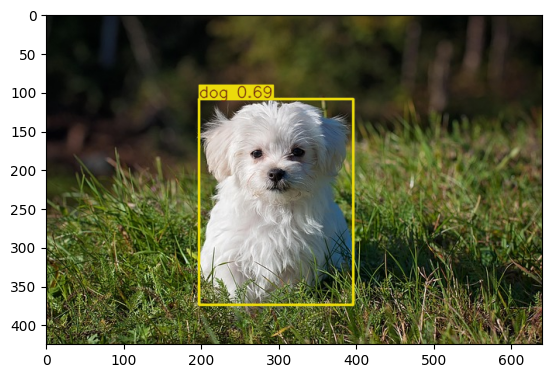

In [37]:
# 모델이 바운딩박스 표현한 이미지를 확인
result[0].plot()

plt.imshow(result[0].plot())
plt.show()

In [41]:
inference = cv2.cvtColor(result[0].plot(), cv2.COLOR_RGB2BGR)
cv2.imshow("dog", inference )
cv2.waitKey(0)
cv2.destroyAllWindows()

In [46]:
# 영상을 학습모델로 탐지해보자

# 프레임 고정 코드
# 1.비디오 객체 생성
cap = cv2.VideoCapture("./data/dog.mp4")
# cv2.VideoCapture(0) # 카메라 연결

# 프레임 표시 최대 크기(더 줄이려면 값을 낮추세요: 예 240x180, 160x120)
max_w, max_h = 320*2, 240*2

# 2.영상은 이미지의 배열 => 반복문 사용해야한다.while문 사용
# 영상 파일을 제대로 읽어 왔는지에 대한 여부
while cap.isOpened() :
    success, frame = cap.read() # success : 프레임 잘 읽어왔는지에 대한 여부
                                # frame : 프레임(이미지)

    # 프레임 읽기에 성공한 경우
    if success :
        # 프레임 리사이즈: 비율 유지하며 max_w x max_h 안으로만 축소
        h, w = frame.shape[:2]
        scale = min(max_w / float(w), max_h / float(h), 1.0)  # 확대 금지
        if scale < 1.0:
            new_w = max(1, int(round(w * scale)))
            new_h = max(1, int(round(h * scale)))
            frame = cv2.resize(frame, (new_w, new_h), interpolation=cv2.INTER_AREA)

        # 모델예측
        result = model(frame)  # model(...): Ultralytics YOLO 추론 실행
                               # - 입력: 단일 프레임(ndarray, HxWx3), OpenCV의 BGR 그대로 전달해도 내부에서 처리됨
                               # - 출력: list[Results] (입력 이미지 개수만큼 Results 객체 반환; 여기서는 길이 1)
                               # - GPU가 있으면 자동 사용(CUDA), 없으면 CPU로 추론

        annotated_frame =result[0].plot()  # 첫 번째 Results에 대해 시각화된 이미지를 생성
                                           # - 상자/레이블/점수를 그려ㅂ 넣은 이미지(ndarray) 반환
                                           # - 원시 예측은 result[0].boxes.xyxy(좌표), .conf(신뢰도), .cls(클래스)로 접근 가능
                                           # - 색이 이상해 보이면 OpenCV 표시용으로 BGR 변환:
                                           #   annotated_frame = cv2.cvtColor(annotated_frame, cv2.COLOR_RGB2BGR)

        cv2.imshow("dog", annotated_frame)  # 주석이 그려진 프레임을 새 창("dog")에 표시
                                            # - 영상 루프에서는 imshow 후 반드시 waitKey(...) 호출이 필요

        # "q" 키를 입력하면 while 루프를 종료
        if cv2.waitKey(1) == ord("q"):
            print("사용자에 의해 종료")
            break

    else :
        print("프레임 읽기에 실패했습니다.")
        break

# 자원 해제
cap.release()
cv2.destroyAllWindows() # 모든 창 닫기


0: 384x640 (no detections), 105.0ms
Speed: 3.9ms preprocess, 105.0ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 82.4ms
Speed: 1.6ms preprocess, 82.4ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 74.3ms
Speed: 2.2ms preprocess, 74.3ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 64.9ms
Speed: 1.9ms preprocess, 64.9ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 62.9ms
Speed: 1.2ms preprocess, 62.9ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 dog, 62.5ms
Speed: 2.3ms preprocess, 62.5ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 dog, 59.2ms
Speed: 2.1ms preprocess, 59.2ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 dog, 64.0ms
Speed: 1.6ms preprocess, 64.0ms inference, 0.7ms postprocess p

In [ ]:
# 내일 허깅페이스에서 모델 가져와서 사용하고.
# doc 2 vec(구식) => 병합분집 => 클러스터별 페르소타 => action (LD topping modeling)
# transformer(trand) 기반 모델 학습 디코더() 인코더=> 벌트계열 (임베딩이 장점 septet 벌트 모델 등을 )